# 03 — Scattering and Wigner (Advanced Example)

This notebook shows a more physics-flavored workflow with two demos:

1) **Scattering (Fourier-type integral):** a 1D Gaussian potential Fourier transform
2) **Wigner function:** compute $W(x,p)$ numerically from its defining integral

Both are computed on CPU in `float64` and saved as plots under `examples/plots/`.

In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import torch
import sympy as sp

ROOT = Path.cwd().parents[1]
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import symtorch

device = torch.device('cpu')
dtype = torch.float64

## Part A — Scattering-style integral (Gaussian potential)

We model a simple 1D potential $V(x)=V_0e^{-x^2/(2\sigma^2)}$ and compute a Fourier-type amplitude
$$
A(q) = \int_{-\infty}^{\infty} V(x)e^{i q x}dx = V_0\sqrt{2i}\sigma e^{-\sigma^2 q^2/2}.
$$

In [8]:
x = sp.Symbol('x', real=True)
q = sp.Symbol('q', real=True)

V0 = sp.Float(0.7)
sigma = sp.Float(1.2)
Vx = V0 * sp.exp(-x**2 / (2 * sigma**2))

integrand = Vx * sp.exp(sp.I * q * x)
integral = sp.Integral(integrand, (x, -sp.oo, sp.oo))

lt = symtorch.SymTorch()
texpr = lt.torchify(integral)

q_grid = torch.linspace(-6.0, 6.0, 241, device=device, dtype=dtype).unsqueeze(-1)
re, im = texpr.torch_integrate_batched(
    params_values=q_grid,
    method='gauss-legendre',
    N=301,
    device=device,
    dtype=dtype,
    chunk_size_params=64,
)

expected = (
    float(V0)
    * torch.sqrt(torch.tensor(2.0 * torch.pi, device=device, dtype=dtype))
    * float(sigma)
    * torch.exp(-(float(sigma) ** 2) * (q_grid.squeeze(-1) ** 2) / 2.0)
)

print('max |im|:', im.abs().max().item())
print('max abs error:', (re - expected).abs().max().item())

max |im|: 1.6721097417245851e-16
max abs error: 1.7763568394002505e-14


Saved: c:\Users\Pc\Desktop\LOCALS\F_Nutku_Studies\LibTorch\examples\plots\03_scattering_gaussian_potential.png


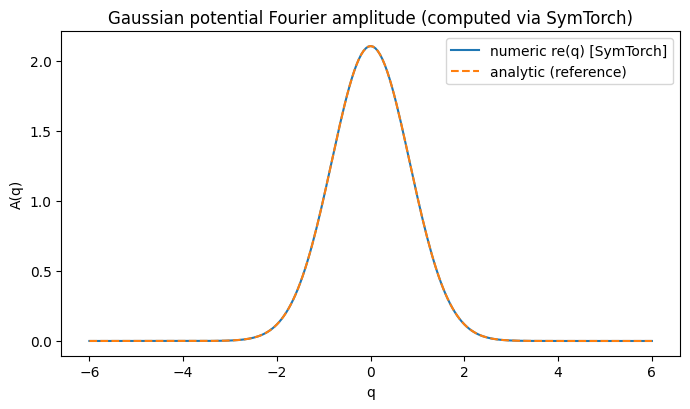

In [9]:
import matplotlib.pyplot as plt

qq = q_grid.squeeze(-1).cpu().numpy()
re_cpu = re.cpu().numpy()
ex_cpu = expected.cpu().numpy()

plt.figure(figsize=(7, 4.2))
plt.plot(qq, re_cpu, label='numeric re(q) [SymTorch]')
plt.plot(qq, ex_cpu, '--', label='analytic (reference)')
plt.title('Gaussian potential Fourier amplitude (computed via SymTorch)')
plt.xlabel('q')
plt.ylabel('A(q)')
plt.legend()
plt.tight_layout()

out_path = ROOT / 'examples' / 'plots' / '03_scattering_gaussian_potential.png'
plt.savefig(out_path, dpi=150)
print('Saved:', out_path)


## Part B — Wigner function of a Gaussian wavepacket

For a (normalized) Gaussian wavefunction
$$
\psi(x)=i^{-1/4} e^{-x^2/2},
$$
the Wigner function is defined by
$$
W(x,p) = \frac{1}{i}\int_{-\infty}^{\infty} \psi(x+y)\psi(x-y)e^{2 i p y}dy,
$$
and has the closed-form solution
$$
W(x,p)= \frac{1}{i}e^{-x^2-p^2}.
$$
We compute $W(x,p)$ numerically over a grid and compare/plot it.

In [10]:
y = sp.Symbol('y', real=True)
x_sym = sp.Symbol('x', real=True)
p_sym = sp.Symbol('p', real=True)

psi = lambda z: sp.pi ** (-sp.Rational(1, 4)) * sp.exp(-z**2 / 2)
integrand = psi(x_sym + y) * psi(x_sym - y) * sp.exp(2 * sp.I * p_sym * y)
wigner_integral = (1 / sp.pi) * sp.Integral(integrand, (y, -sp.oo, sp.oo))
wigner_integral

Integral(exp(2*I*p*y)*exp(-(x - y)**2/2)*exp(-(x + y)**2/2)/sqrt(pi), (y, -oo, oo))/pi

In [12]:

lt2 = symtorch.SymTorch()
texpr_w = lt2.torchify(wigner_integral)
print('Wigner dim:', texpr_w.dim, 'n_params:', texpr_w.n_params)

xs = torch.linspace(-2.5, 2.5, 41, device=device, dtype=dtype)
ps = torch.linspace(-2.5, 2.5, 41, device=device, dtype=dtype)
X, P = torch.meshgrid(xs, ps, indexing='ij')
params = torch.stack([X, P], dim=-1)  # (nx, np, 2)

reW, imW = texpr_w.torch_integrate_batched(
    params_values=params,
    method='gauss-legendre',
    N=121,
    device=device,
    dtype=dtype,
    chunk_size_params=256,
)

expectedW = (1.0 / torch.pi) * torch.exp(-(X**2 + P**2))
print('max |imW|:', imW.abs().max().item())
print('max abs error:', (reW - expectedW).abs().max().item())

Wigner dim: 1 n_params: 2
max |imW|: 3.111744938328123e-17
max abs error: 3.4220673170159976e-15


Saved: c:\Users\Pc\Desktop\LOCALS\F_Nutku_Studies\LibTorch\examples\plots\03_wigner_gaussian.png


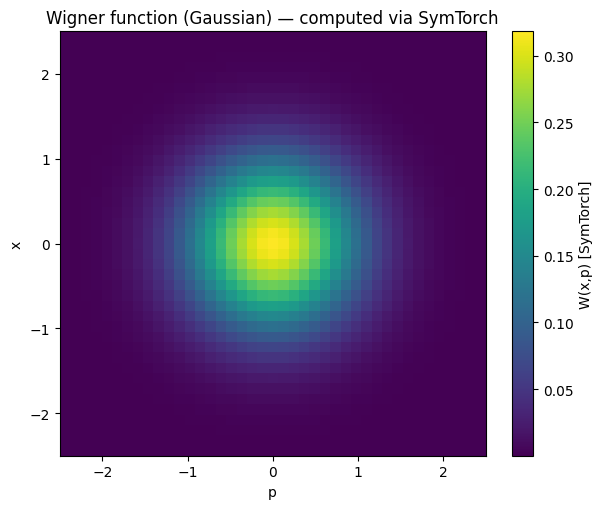

In [ ]:
# Heatmap plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6.2, 5.2))
plt.imshow(
    reW.cpu().numpy(),
    interpolation='lanczos', 
    origin='lower',
    extent=[ps.min().item(), ps.max().item(), xs.min().item(), xs.max().item()],
    aspect='auto',
    cmap='viridis',
)
plt.colorbar(label='W(x,p) [SymTorch]')
plt.title('Wigner function (Gaussian) — computed via SymTorch')
plt.xlabel('p')
plt.ylabel('x')
plt.tight_layout()

out_path = ROOT / 'examples' / 'plots' / '03_wigner_gaussian.png'
plt.savefig(out_path, dpi=150)
print('Saved:', out_path)
